# Exploratory Data Analysis — Hospital Readmission (30k)

**Dataset :** `data/hospital_readmissions_30k.csv`  
**Cible :** `readmitted_30_days` — le patient a-t-il ete readmis dans les 30 jours ?  
**Objectif :** comprendre la structure, la qualite et les relations dans les donnees avant la modelisation.

---
| Section | Contenu |
|---|---|
| 1 | Chargement — shape, dtypes, head, describe |
| 2 | Qualite — valeurs nulles, doublons |
| 3 | Desequilibre des classes |
| 4 | Distributions numeriques |
| 5 | Distributions categorielles |
| 6 | Analyse de blood_pressure |
| 7 | Boxplots par cible |
| 8 | Matrice de correlation |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100

DATA_PATH = '../data/hospital_readmissions_30k.csv'
TARGET    = 'readmitted_30_days'
PALETTE   = {'Yes': '#e53935', 'No': '#43a047'}

---
## 1. Chargement des donnees

In [2]:
df = pd.read_csv(DATA_PATH, sep=';')
print(f'Shape  : {df.shape[0]:,} lignes  x  {df.shape[1]} colonnes')
print(f'Colonnes : {df.columns.tolist()}')

Shape  : 30,000 lignes  x  12 colonnes
Colonnes : ['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']


In [3]:
print('--- head(10) ---')
display(df.head(10))

--- head(10) ---


,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No
5,6,75,Female,139/100,194,33.5,No,Yes,0,10,Home,No
6,7,47,Male,139/79,168,27.1,No,Yes,5,8,Home,No
7,8,18,Other,153/81,210,26.3,No,No,5,2,Home,No
8,9,68,Male,111/76,218,30.4,No,Yes,3,8,Home,No
9,10,23,Female,142/72,186,21.3,No,No,3,3,Home,No


In [4]:
print('--- Types de donnees ---')
dtype_info = pd.DataFrame({
    'dtype'      : df.dtypes,
    'non_null'   : df.notnull().sum(),
    'n_unique'   : df.nunique(),
    'exemple'    : df.iloc[0]
})
display(dtype_info)

--- Types de donnees ---


,dtype,non_null,n_unique,exemple
patient_id,int64,30000,30000,1
age,int64,30000,73,74
gender,object,30000,3,Other
blood_pressure,object,30000,1581,130/72
cholesterol,int64,30000,151,240
bmi,float64,30000,221,31.5
diabetes,object,30000,2,Yes
hypertension,object,30000,2,No
medication_count,int64,30000,11,5
length_of_stay,int64,30000,10,1


In [5]:
print('--- Statistiques descriptives ---')
display(df.describe(include='all').T)

--- Statistiques descriptives ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,30000.0,NaN,NaN,NaN,15000.5,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
age,30000.0,NaN,NaN,NaN,53.884233,21.056485,18.0,36.0,54.0,72.0,90.0
gender,30000,3,Male,10097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
blood_pressure,30000,1581,143/94,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cholesterol,30000.0,NaN,NaN,NaN,225.2604,43.585671,150.0,188.0,225.0,263.0,300.0
bmi,30000.0,NaN,NaN,NaN,28.946263,6.348204,18.0,23.4,28.9,34.5,40.0
diabetes,30000,2,No,15051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hypertension,30000,2,No,15022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medication_count,30000.0,NaN,NaN,NaN,5.012267,3.166383,0.0,2.0,5.0,8.0,10.0
length_of_stay,30000.0,NaN,NaN,NaN,5.5029,2.867298,1.0,3.0,5.0,8.0,10.0


---
## 2. Qualite des donnees — valeurs nulles et doublons

In [6]:
# Valeurs nulles
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_df     = pd.DataFrame({'count': null_counts, 'pct_%': null_pct})

print(f'Valeurs nulles total : {null_counts.sum()}')
display(null_df)

# Doublons
n_dup = df.duplicated().sum()
print(f'\nLignes dupliquees : {n_dup}')

if null_counts.sum() == 0 and n_dup == 0:
    print('\n=> Dataset propre : aucune valeur manquante, aucun doublon.')

Valeurs nulles total : 0


,count,pct_%
patient_id,0,0.0
age,0,0.0
gender,0,0.0
blood_pressure,0,0.0
cholesterol,0,0.0
bmi,0,0.0
diabetes,0,0.0
hypertension,0,0.0
medication_count,0,0.0
length_of_stay,0,0.0



Lignes dupliquees : 0

=> Dataset propre : aucune valeur manquante, aucun doublon.


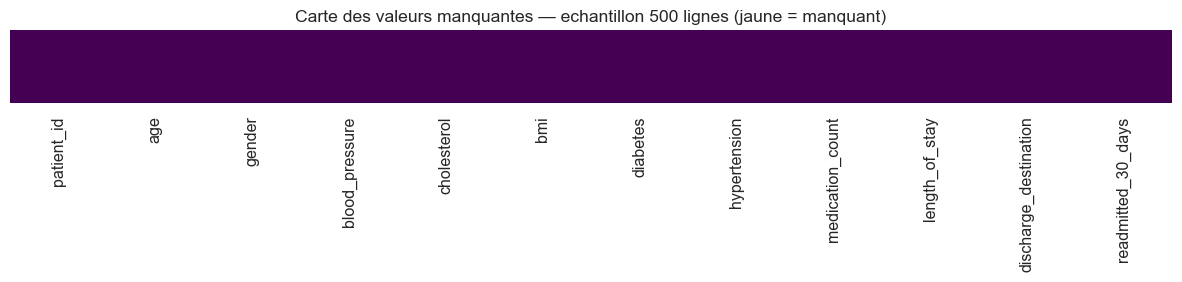

In [7]:
# Heatmap valeurs manquantes (meme sans manquant, utile comme verification visuelle)
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(
    df.sample(500, random_state=42).isnull(),
    cbar=False, yticklabels=False, cmap='viridis', ax=ax
)
ax.set_title('Carte des valeurs manquantes — echantillon 500 lignes (jaune = manquant)')
plt.tight_layout()
plt.show()

---
## 3. Desequilibre des classes

La cible `readmitted_30_days` est binaire (Yes / No).  
**Avec 12.2% de positifs**, le dataset est fortement desequilibre — ce qui justifie l'utilisation de SMOTE lors du preprocessing.

,count,pct_%
readmitted_30_days,,
No,26326,87.75
Yes,3674,12.25


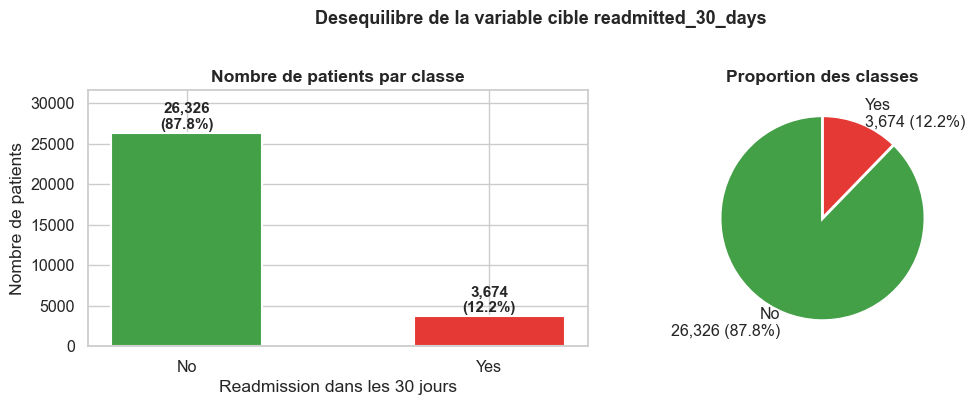


Ratio de desequilibre : 1 positif pour 7.2 negatifs


In [8]:
counts = df[TARGET].value_counts()
pcts   = df[TARGET].value_counts(normalize=True) * 100

summary = pd.DataFrame({'count': counts, 'pct_%': pcts.round(2)})
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# -- Barplot
bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE[k] for k in counts.index],
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val, pct in zip(bars, counts.values, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 150,
                 f'{val:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Nombre de patients par classe', fontweight='bold')
axes[0].set_xlabel('Readmission dans les 30 jours')
axes[0].set_ylabel('Nombre de patients')
axes[0].set_ylim(0, counts.max() * 1.2)

# -- Pie
axes[1].pie(
    counts.values,
    labels=[f'{k}\n{v:,} ({p:.1f}%)' for k, v, p in zip(counts.index, counts.values, pcts.values)],
    colors=[PALETTE[k] for k in counts.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proportion des classes', fontweight='bold')

plt.suptitle('Desequilibre de la variable cible readmitted_30_days',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'\nRatio de desequilibre : 1 positif pour {counts["No"]/counts["Yes"]:.1f} negatifs')

---
## 4. Distribution des variables numeriques

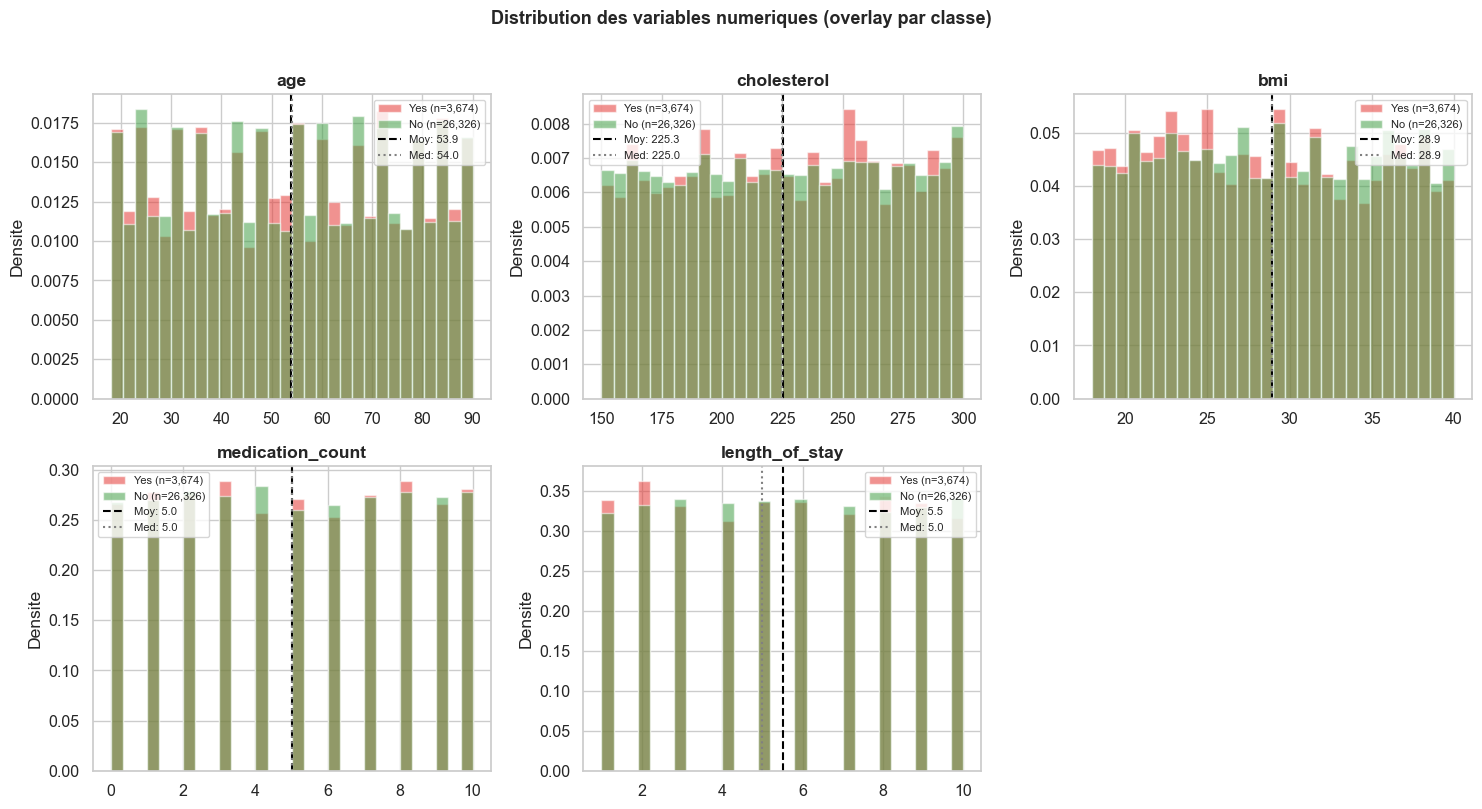

In [9]:
num_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    # Overlay par classe
    for label, color in PALETTE.items():
        subset = df[df[TARGET] == label][col]
        ax.hist(subset, bins=30, alpha=0.55, color=color,
                label=f'{label} (n={len(subset):,})', density=True)
    ax.axvline(df[col].mean(),   color='black', linestyle='--',
               linewidth=1.5, label=f'Moy: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='gray',  linestyle=':',
               linewidth=1.5, label=f'Med: {df[col].median():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Densite')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribution des variables numeriques (overlay par classe)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# Statistiques numeriques par classe
print('=== Moyennes par classe ===')
display(df.groupby(TARGET)[num_cols].mean().round(2))

=== Moyennes par classe ===


,age,cholesterol,bmi,medication_count,length_of_stay
readmitted_30_days,,,,,
No,53.88,225.20,28.98,5.01,5.51
Yes,53.91,225.73,28.72,5.01,5.45


---
## 5. Distribution des variables categorielles

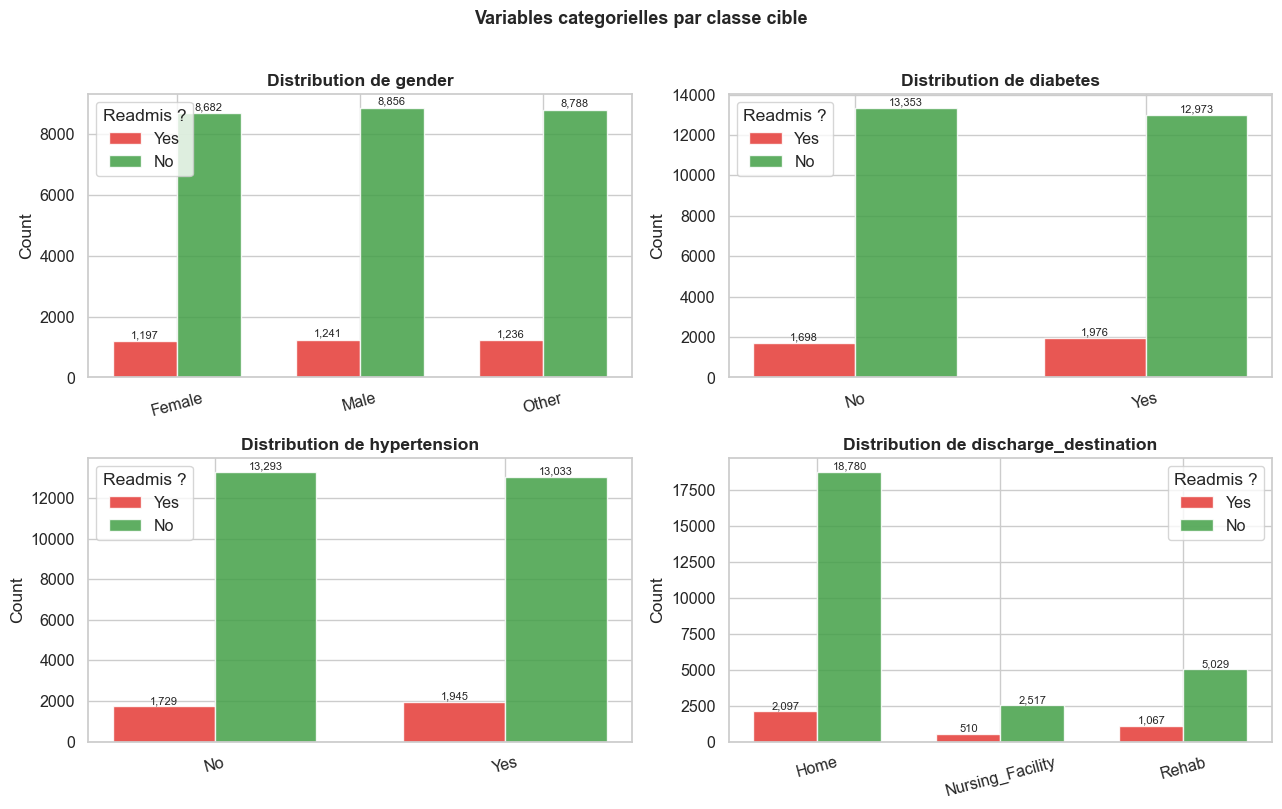

In [11]:
cat_cols = ['gender', 'diabetes', 'hypertension', 'discharge_destination']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    ct = pd.crosstab(df[col], df[TARGET])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    x = np.arange(len(ct.index))
    width = 0.35
    for j, (cls, color) in enumerate(PALETTE.items()):
        vals = ct[cls].values if cls in ct.columns else np.zeros(len(ct))
        bars = ax.bar(x + j*width, vals, width, label=cls,
                      color=color, edgecolor='white', alpha=0.85)
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 30, f'{val:,}',
                        ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(ct.index, rotation=15)
    ax.set_title(f'Distribution de {col}', fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(title='Readmis ?')

plt.suptitle('Variables categorielles par classe cible',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

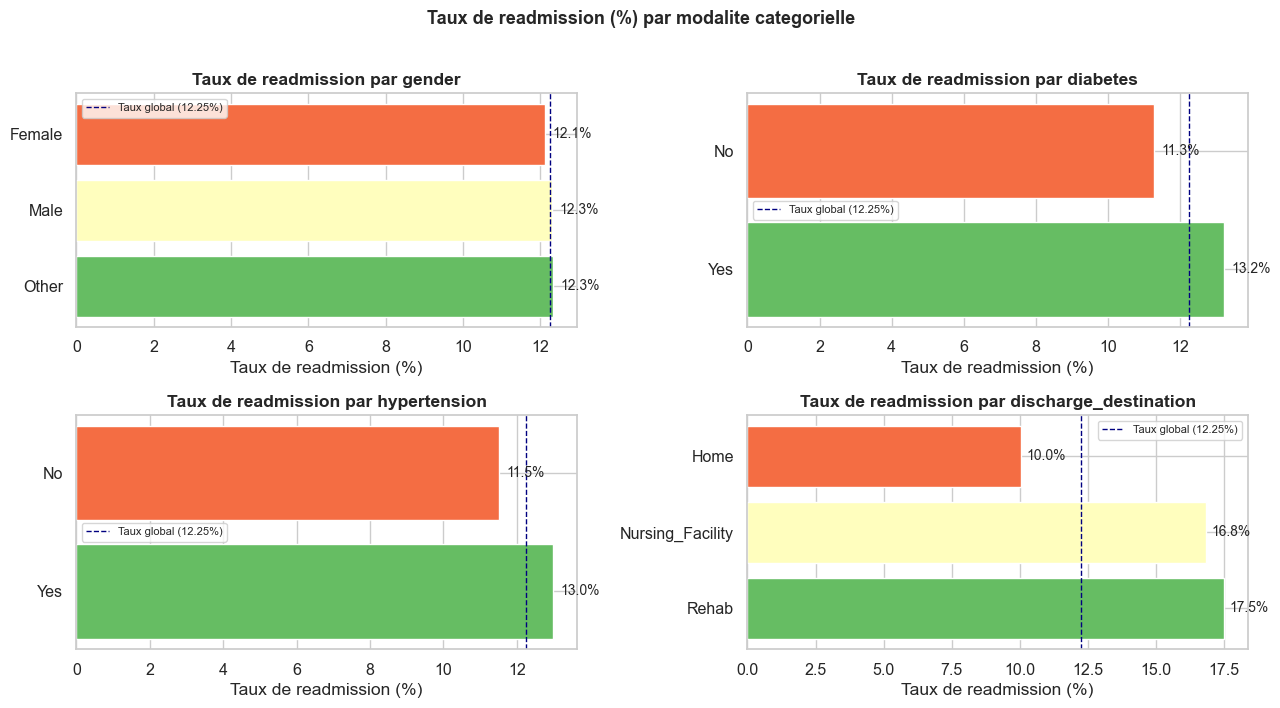

In [12]:
# Taux de readmission par modalite
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    rate = df.groupby(col)[TARGET].apply(lambda x: (x=='Yes').mean() * 100).sort_values(ascending=False)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(rate)))
    bars = ax.barh(rate.index, rate.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, rate.values):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)
    ax.axvline(12.25, color='navy', linestyle='--', linewidth=1, label='Taux global (12.25%)')
    ax.set_title(f'Taux de readmission par {col}', fontweight='bold')
    ax.set_xlabel('Taux de readmission (%)')
    ax.legend(fontsize=8)

plt.suptitle('Taux de readmission (%) par modalite categorielle',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Analyse de blood_pressure

`blood_pressure` est stockee comme une chaine `'130/72'` (systolique/diastolique).  
Elle doit etre decomposee en deux variables numeriques pour etre exploitable.

In [13]:
print('Valeurs brutes de blood_pressure (5 premiers) :')
print(df['blood_pressure'].head().tolist())
print(f'Nb valeurs uniques : {df["blood_pressure"].nunique()}')

bp = df['blood_pressure'].str.split('/', expand=True).astype(float)
bp.columns = ['bp_sys', 'bp_dia']
df_bp = df.join(bp)

print(f'\nbp_sys : min={bp["bp_sys"].min():.0f}  max={bp["bp_sys"].max():.0f}  moy={bp["bp_sys"].mean():.1f}')
print(f'bp_dia : min={bp["bp_dia"].min():.0f}  max={bp["bp_dia"].max():.0f}  moy={bp["bp_dia"].mean():.1f}')

Valeurs brutes de blood_pressure (5 premiers) :
['130/72', '120/92', '135/78', '123/80', '135/84']
Nb valeurs uniques : 1581

bp_sys : min=110  max=160  moy=135.0
bp_dia : min=70  max=100  moy=85.0


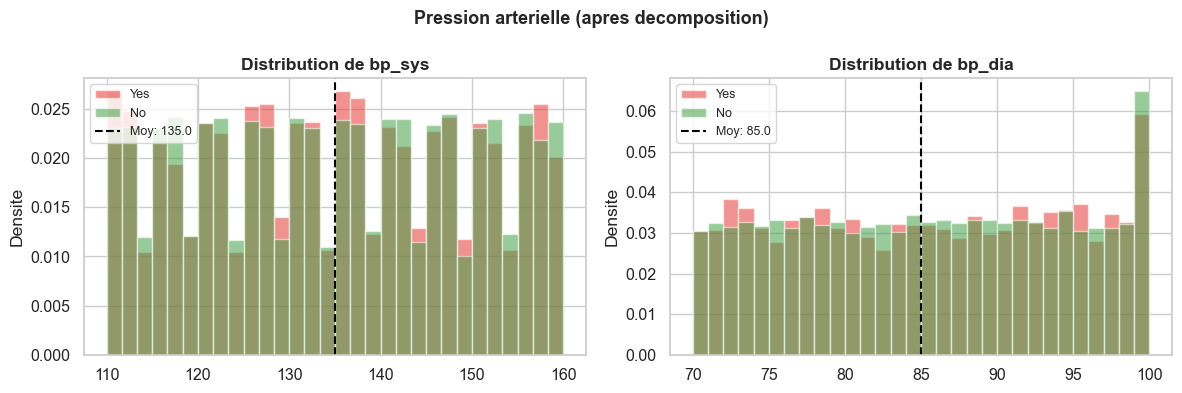

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color in zip(axes, ['bp_sys', 'bp_dia'], ['#7b1fa2', '#0288d1']):
    for label, lc in PALETTE.items():
        subset = df_bp[df_bp[TARGET] == label][col]
        ax.hist(subset, bins=30, alpha=0.55, color=lc,
                label=label, density=True)
    ax.axvline(df_bp[col].mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Moy: {df_bp[col].mean():.1f}')
    ax.set_title(f'Distribution de {col}', fontweight='bold')
    ax.set_ylabel('Densite')
    ax.legend(fontsize=9)

plt.suptitle('Pression arterielle (apres decomposition)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Boxplots de age / bmi / cholesterol selon la cible

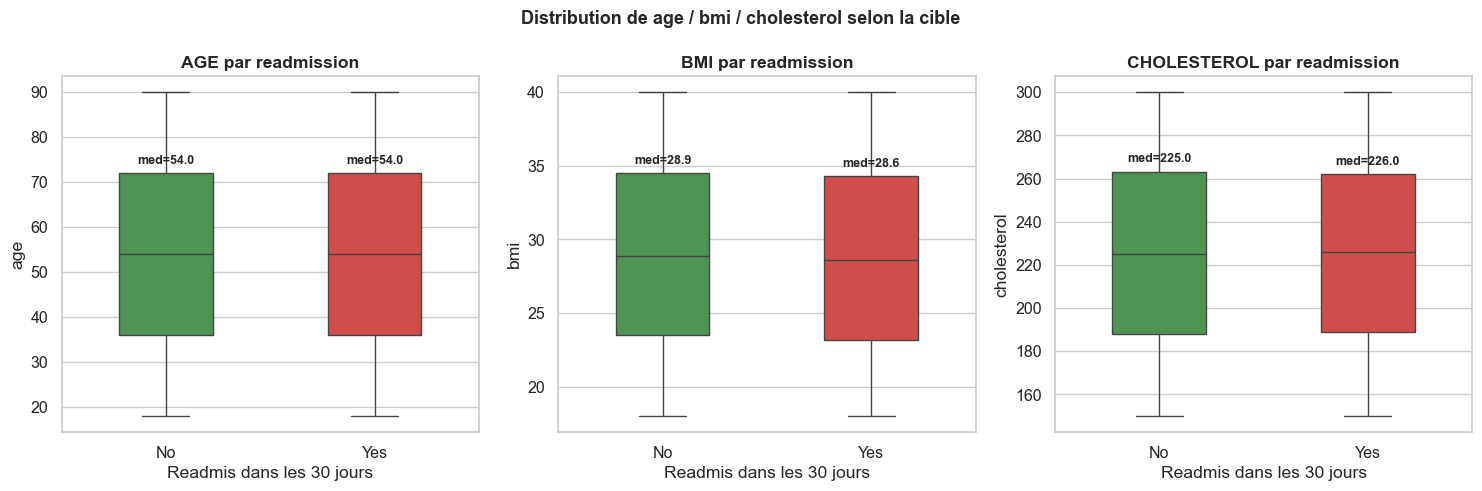

In [15]:
key_vars = ['age', 'bmi', 'cholesterol']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var in zip(axes, key_vars):
    sns.boxplot(
        data=df, x=TARGET, y=var,
        palette=PALETTE, width=0.45,
        flierprops=dict(marker='o', markersize=2.5, alpha=0.3),
        order=['No', 'Yes'],
        ax=ax
    )
    # Annote la mediane
    for idx, grp in enumerate(['No', 'Yes']):
        med = df[df[TARGET] == grp][var].median()
        q75 = df[df[TARGET] == grp][var].quantile(0.75)
        ax.text(idx, q75 + (df[var].max() - df[var].min()) * 0.03,
                f'med={med:.1f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'{var.upper()} par readmission', fontweight='bold')
    ax.set_xlabel('Readmis dans les 30 jours')

plt.suptitle('Distribution de age / bmi / cholesterol selon la cible',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

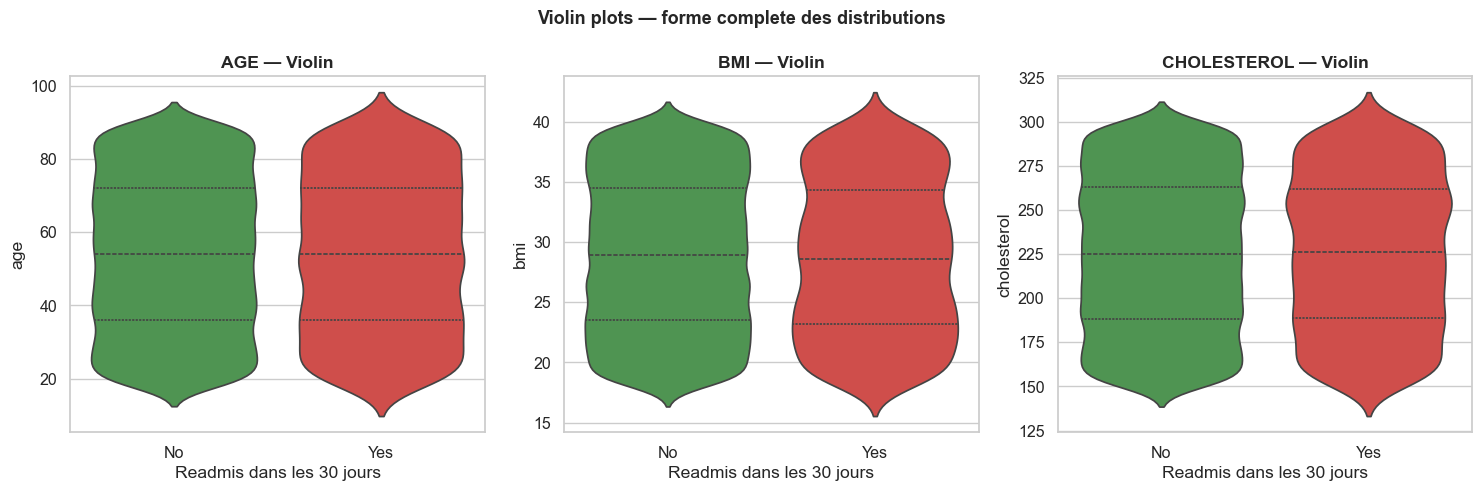

In [16]:
# Violin plots — montre la forme complete de la distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var in zip(axes, key_vars):
    sns.violinplot(
        data=df, x=TARGET, y=var,
        palette=PALETTE, inner='quartile',
        order=['No', 'Yes'], ax=ax
    )
    ax.set_title(f'{var.upper()} — Violin', fontweight='bold')
    ax.set_xlabel('Readmis dans les 30 jours')

plt.suptitle('Violin plots — forme complete des distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Tableau : moyenne et ecart-type par classe
print('=== Statistiques des variables cles par classe ===')
stats = df.groupby(TARGET)[key_vars].agg(['mean', 'median', 'std']).round(2)
display(stats)

=== Statistiques des variables cles par classe ===


age                  bmi              cholesterol  \
                     mean median    std   mean median   std        mean   
readmitted_30_days                                                        
No                  53.88   54.0  21.05  28.98   28.9  6.35      225.20   
Yes                 53.91   54.0  21.12  28.72   28.6  6.34      225.73   

                                  
                   median    std  
readmitted_30_days                
No                  225.0  43.63  
Yes                 226.0  43.27

---
## 8. Matrice de correlation

In [18]:
# Construire un DataFrame numerique
df_corr = df.copy()

# Decomposer blood_pressure
bp = df_corr['blood_pressure'].str.split('/', expand=True).astype(float)
df_corr['bp_sys']  = bp[0]
df_corr['bp_dia']  = bp[1]
df_corr = df_corr.drop(columns=['blood_pressure', 'patient_id'])

# Encoder les binaires
bin_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0, 'Other': -1}
for col in ['gender', 'diabetes', 'hypertension', TARGET]:
    df_corr[col] = df_corr[col].map(bin_map)

# Encoder discharge_destination
df_corr['discharge_destination'] = df_corr['discharge_destination'].astype('category').cat.codes

corr = df_corr.select_dtypes(include=[np.number]).corr()

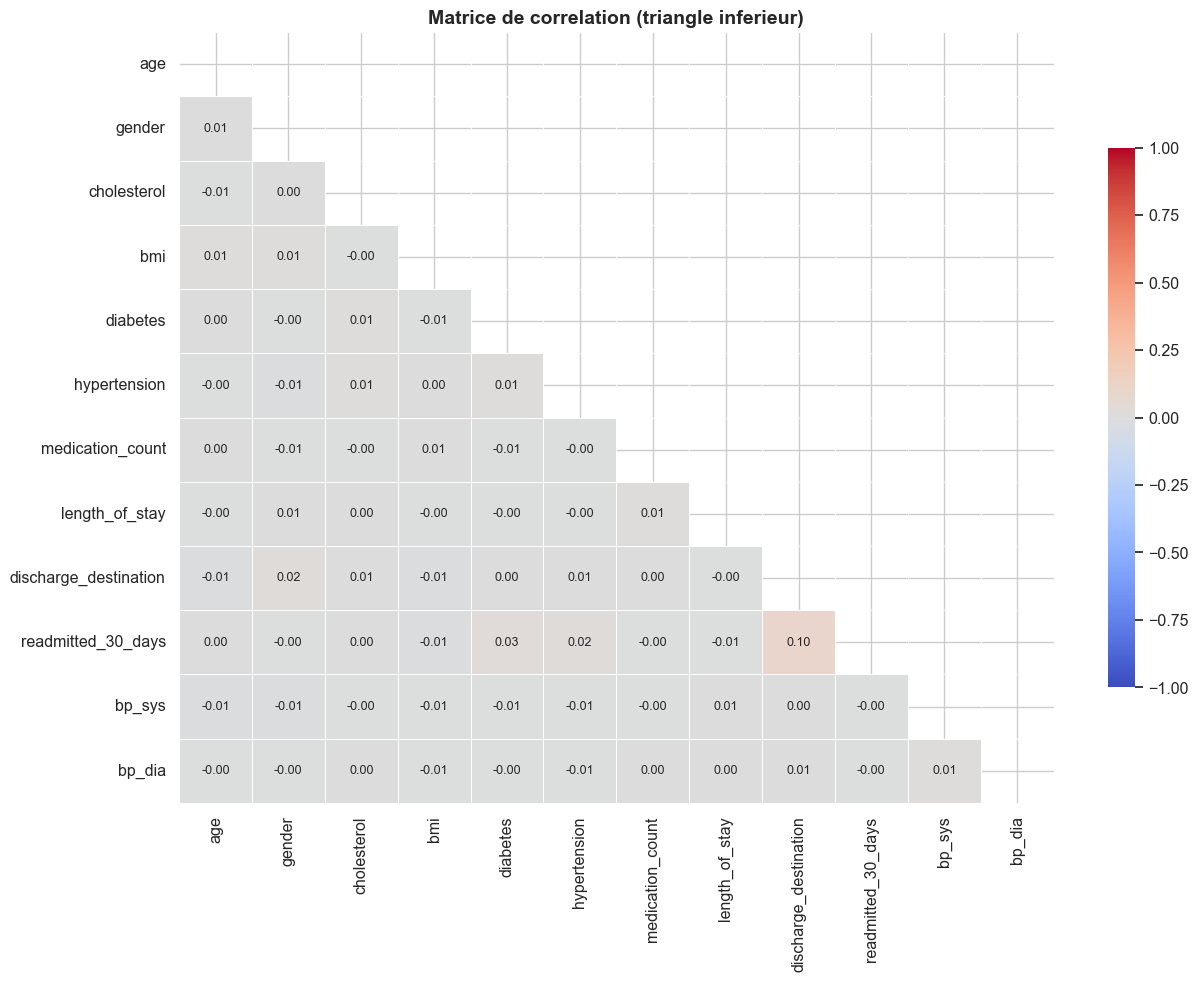

In [19]:
# Heatmap complete (triangle inferieur)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.7},
    ax=ax
)
ax.set_title('Matrice de correlation (triangle inferieur)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

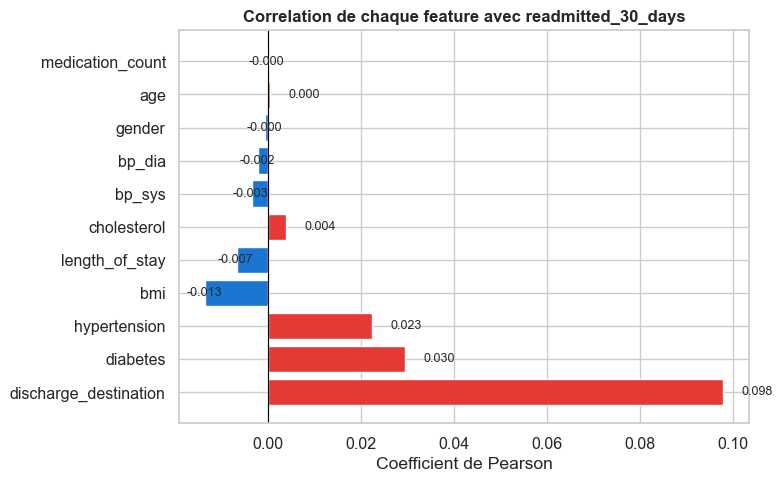


Top 5 correlations positives avec la cible :
discharge_destination    0.097919
diabetes                 0.029538
hypertension             0.022511
cholesterol              0.003983
age                      0.000436

Top 5 correlations negatives avec la cible :
bmi              -0.013472
length_of_stay   -0.006655
bp_sys           -0.003442
bp_dia           -0.002012
gender           -0.000489


In [20]:
# Correlations avec la cible — classees par valeur absolue
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e53935' if v >= 0 else '#1976d2' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, target_corr.values):
    offset = 0.004 if val >= 0 else -0.004
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Correlation de chaque feature avec readmitted_30_days',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient de Pearson')
plt.tight_layout()
plt.show()

print('\nTop 5 correlations positives avec la cible :')
print(target_corr[target_corr > 0].head(5).to_string())
print('\nTop 5 correlations negatives avec la cible :')
print(target_corr[target_corr < 0].head(5).to_string())

---
## Synthese EDA

| Observation | Detail |
|---|---|
| **Dataset** | 30 000 patients, 12 colonnes, aucune valeur manquante, aucun doublon |
| **Cible** | `readmitted_30_days` : 12.25% Yes / 87.75% No — fort desequilibre |
| **Numeriques** | age [18-90], bmi [18-40], cholesterol [150-300], medication_count [0-10], length_of_stay [1-10] |
| **Categorielles** | gender (M/F/Other ~equireparti), diabetes (50/50), hypertension (50/50) |
| **blood_pressure** | Format 'sys/dia' -> a decomposer en 2 features numeriques |
| **Correlations** | Faibles avec la cible : donnees probablement synthetiques |
| **Prochaine etape** | `02_preprocessing.ipynb` — nettoyage, encodage, SMOTE |